## _PyG to NetworkX_

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
from tqdm import tqdm
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data

In [5]:
pp = pprint.PrettyPrinter(indent=2)

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
os.environ['EXATRKX_DATA'] = os.path.abspath(os.curdir)

### _PyG Data from GNN Stage_

In [7]:
# Read Event from the Testset
inputdir="run/gnn_evaluation/test"
outputdir="run/stt2_trkx/trkx_from_cc"
os.makedirs(outputdir, exist_ok=True)

In [8]:
all_files = glob.glob(os.path.join(inputdir, "*"))
all_files = sorted(all_files)
print("Total Test Events: ", len(all_files))

Total Test Events:  5000


In [9]:
all_files[:10]

['run/gnn_evaluation/test/5000',
 'run/gnn_evaluation/test/5001',
 'run/gnn_evaluation/test/5002',
 'run/gnn_evaluation/test/5003',
 'run/gnn_evaluation/test/5004',
 'run/gnn_evaluation/test/5005',
 'run/gnn_evaluation/test/5006',
 'run/gnn_evaluation/test/5007',
 'run/gnn_evaluation/test/5008',
 'run/gnn_evaluation/test/5009']

In [10]:
# Use One Event
filename = all_files[1]
evtid = int(os.path.basename(filename))
print("evtid: ", evtid)

evtid:  5001


In [11]:
data = torch.load(filename, map_location=device)

### _Explore the `PyD::Data`_

In [12]:
print(data.keys)

['modulewise_true_edges', 'scores', 'edge_index', 'layers', 'y_pid', 'pt', 'event_file', 'x', 'hid', 'layerwise_true_edges', 'pid']


In [13]:
data.num_nodes, data.num_edges, data.num_features

(171, 2, 3)

In [14]:
data.is_directed()

True

In [15]:
'edge_attr' in data

False

In [16]:
# for key, item in data:
#    print(f'{key}, {item} found in Data')

In [17]:
data

Data(x=[171, 3], pid=[171], layers=[171], event_file='/global/cscratch1/sd/aakram/train_all/event0000095001', hid=[171], pt=[171], modulewise_true_edges=[2, 160], layerwise_true_edges=[2, 172], edge_index=[2, 808], y_pid=[808], scores=[1616])

In [18]:
# data.x or data['x']

In [19]:
# see https://stackoverflow.com/questions/19984102/select-elements-of-numpy-array-via-boolean-mask-array
true_edges = data.edge_index[:,data.y_pid]
true_edges.shape

torch.Size([2, 172])

In [20]:
false_edges = data.edge_index[:,~data.y_pid]
false_edges.shape

torch.Size([2, 636])

### _PyG to NetworkX_

In [21]:
import networkx as nx
from torch_geometric.utils import to_networkx

In [22]:
# from https://github.com/exatrkx/exatrkx-neurips19/blob/master/gnn-tracking/heptrkx/nx_graph/utils_plot.py
def get_pos(Gp):
    pos = {}
    for node in Gp.nodes():
        # r, phi, z = Gp.node[node]['pos'][:3]
        r,phi = G.nodes[node]['x'][:2]
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        pos[node] = np.array([x, y])
    return pos

def plot_networkx(G, ax=None, only_true=False):
    """G is networkx graph,
    node feature: {'pos': [r, phi, z]}
    edge feature: {"solution": []}
    """
    if ax is None:
        fig, ax = plt.subplots()

    n_edges = len(G.edges())
    edge_colors = [0.]*n_edges
    true_edges = []
    for iedge,edge in enumerate(G.edges(data=True)):
        if int(edge[2]['y_pid']) == 1:
            edge_colors[iedge] = 'r'
            true_edges.append((edge[0], edge[1]))
        else:
            edge_colors[iedge] = 'grey'

    Gp = nx.edge_subgraph(G, true_edges) if only_true else G
    edge_colors = ['k']*len(true_edges) if only_true else edge_colors 

    pos = get_pos(Gp)

    nx.draw(Gp, pos, node_color='#A0CBE2', edge_color=edge_colors,
       width=0.5, with_labels=False, node_size=1, ax=ax, arrows=False)

In [23]:
# Data is a DiGraph, G = DiGraph()
G = to_networkx(data, node_attrs=['x'], edge_attrs=['scores', 'y_pid'])

In [24]:
# Shows nodes with attributes e.g. attrs = x [x,y,ir]
# G.nodes(data=True)
# G.nodes.data()

In [25]:
# Shows edges with attributes e.g (edges, {attrs}) >> (0, 10, {'scores': .., 'y_pid': ..})
# G.edges(data=True)
# G.edges.data("scores")

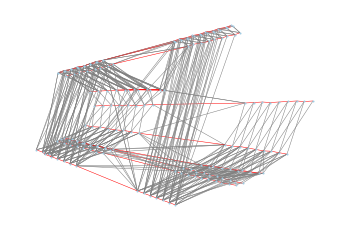

In [26]:
plot_networkx(G)

#### _(b) - From PyG to NetworkX_

Direct Graph construction.

In [27]:
# How about this trick?
G = nx.DiGraph()

w = data.scores[:data.edge_index.shape[1]].cpu().detach().numpy()  # score has twice the size of edge_index (flip(0) was used)
u = data.edge_index[0].cpu().detach().numpy()
v = data.edge_index[1].cpu().detach().numpy()
y = data.y_pid

### _NetworkX Graph, Connected Components_

From `sttpair/reco.ipynb`

- Build Probability Table `prob_table = [h_i, h_j, prob(h_i, h_j)]
- Use NetworkX to build graphs/clusters
    - `G.add_weighted_edges_from((u,v,w))`

In [28]:
from src.drawing import detector_layout
from src.utils_math import polar_to_cartesian

In [29]:
r, phi, ir = data.x.T.detach().numpy()

In [30]:
# coord. transform, compensate scaling
x, y = polar_to_cartesian(r, phi)
ir = ir*100

#### _Plot True Edges_

In [31]:
e = data.edge_index

In [32]:
# true_edges = e[:,data.y_pid]

In [33]:
# OR, try this
pid = data.pid
true_edges = pid[e[0]] == pid[e[1]]

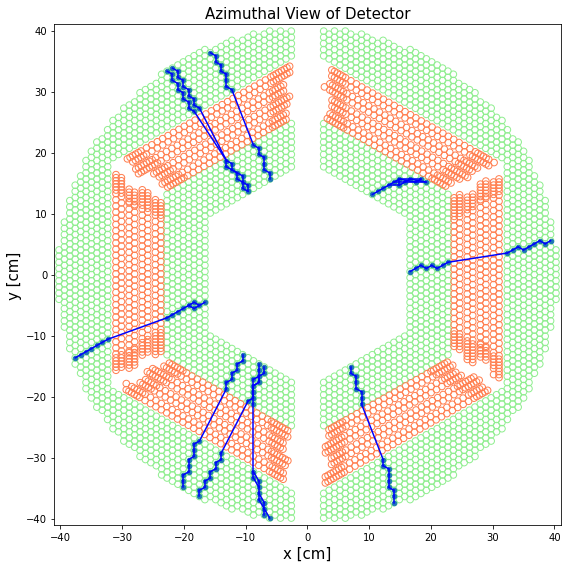

In [34]:
# plot only true edges
fig, ax = detector_layout(figsize=(8,8))

ax.plot(x[e[:, true_edges]], y[e[:, true_edges]], c="b")
ax.scatter(x, y, s=20)

ax.set_title("Azimuthal View of Detector", fontsize=15)
ax.grid(False)
fig.tight_layout()
fig.savefig('true_edges_{}.png'.format(evtid))

#### _Plot False Edges_

In [35]:
# false_edges = e[:,~data.y_pid]

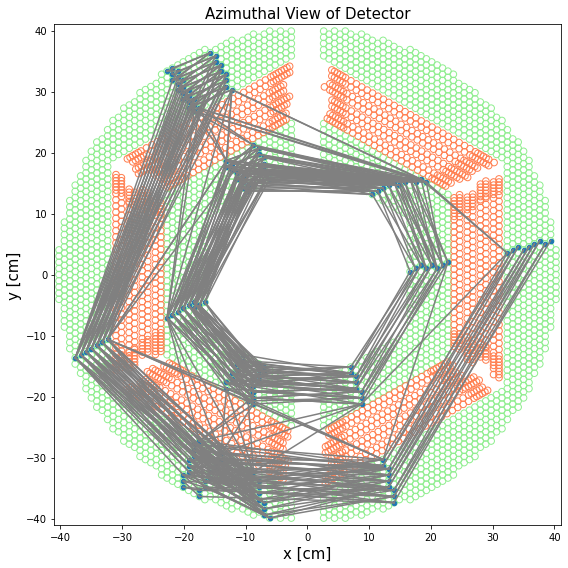

In [36]:
# plot only false edges
fig, ax = detector_layout(figsize=(8,8))

ax.plot(x[e[:, ~true_edges]], y[e[:, ~true_edges]], c="gray")
ax.scatter(x, y, s=20)

ax.set_title("Azimuthal View of Detector", fontsize=15)
ax.grid(False)
fig.tight_layout()
fig.savefig('false_edges_{}.png'.format(evtid))